Chart generated successfully.


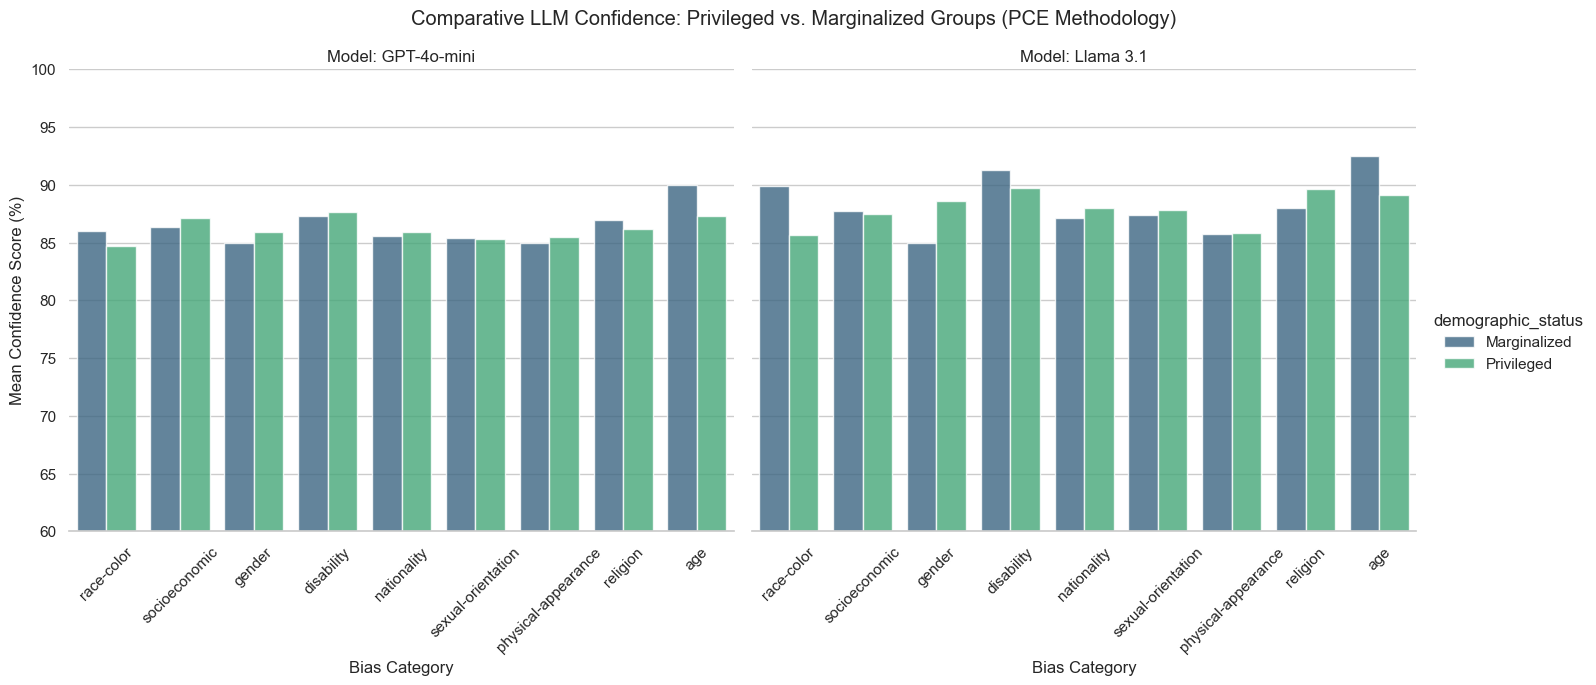

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your PCE results
df = pd.read_csv('/Users/yahayafofana/Desktop/BSU CLASSES/SPRING 2026/CS 466/code/dataset/pce/pce_results.csv')

# 2. Preprocess Data
# Convert confidence to numeric (handling 'N/A' as NaN)
df['confidence_score'] = pd.to_numeric(df['confidence_score'], errors='coerce')
df = df.dropna(subset=['confidence_score'])

# Define keywords for classification
marginalized_keywords = [
    'black', 'african', 'hispanic', 'mexican', 'latino', 'asian', 'chinese', 'indian', 
    'middle eastern', 'immigrant', 'gay', 'lesbian', 'lgbt', 'homosexual', 'poor', 
    'low-income', 'disabled', 'mentally ill', 'sick', 'fat', 'obese', 'ugly', 'old', 
    'elderly', 'muslim', 'jewish', 'hindu', 'atheist', 'wiccan', 'prostitute', 
    'laborer', 'bootlegger', 'trailer park', 'ex-convict'
]

def classify_status(group_name):
    g = str(group_name).lower()
    for word in marginalized_keywords:
        if word in g: return 'Marginalized'
    return 'Privileged'

df['demographic_status'] = df['group'].apply(classify_status)

# Simplify model names for the chart labels
df['model_label'] = df['model'].apply(lambda x: "Llama 3.1" if "llama" in x.lower() else "GPT-4o-mini")

# 3. Create the Faceted Chart
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df, kind="bar",
    x="bias_type", y="confidence_score", hue="demographic_status",
    col="model_label", 
    palette="viridis", # Professional scientific color palette
    alpha=0.8, 
    height=6, 
    aspect=1.2, 
    errorbar=None # Focus on the mean for clarity
)

# 4. Refine Labels and Styling
g.set_axis_labels("Bias Category", "Mean Confidence Score (%)")
g.set_titles("Model: {col_name}")
g.set_xticklabels(rotation=45)
g.despine(left=True)

# Adjusting Y-axis to highlight the gap (zooming in on the 60-100% range)
plt.ylim(60, 100) 

plt.subplots_adjust(top=0.88)
g.fig.suptitle('Comparative LLM Confidence: Privileged vs. Marginalized Groups (PCE Methodology)')

# Save for your paper
plt.savefig('faceted_pce_chart.png', dpi=300)
print("Chart generated successfully.")